In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = next(
    p for p in (cwd, *cwd.parents)
    if (p / "rebound").is_dir() and (p / "src").is_dir()
)
sys.path.insert(0, str(repo_root))

import rebound
import ctypes
import numpy as np
import matplotlib.pyplot as plt

_hj_tree_to_string = rebound.clibrebound.reb_integrator_whfast_hj_tree_to_string
_hj_tree_to_string.argtypes = [ctypes.c_void_p, ctypes.c_char_p, ctypes.c_size_t]
_hj_tree_to_string.restype = ctypes.c_int

def hj_tree_string(sim):
    size = 1024

    while True:
        buf = ctypes.create_string_buffer(size)
        n = _hj_tree_to_string(ctypes.byref(sim), buf, size)

        if n < 0:
            raise RuntimeError("Cannot determine HJ tree.")

        if n < size:
            return buf.value.decode()

        size = n + 1

def setup_scaled_outer_solar_system(factor=50):
    sim = rebound.Simulation()
    sim.units = ("yr", "AU", "Msun")
    sim.G = 4*np.pi**2

    # Sun
    sim.add(m=1.0)

    # JPL approximate J2000 elements:
    # name, scaled mass, a, e, inc, Omega, long_peri, mean_longitude
    planets = [
        ("Jupiter", factor*9.545655705140133e-4,
         5.20288700, 0.04838624, 1.30439695, 100.47390909, 14.72847983, 34.39644051),

        ("Saturn", factor*2.8580617258495224e-4,
         9.53667594, 0.05386179, 2.48599187, 113.66242448, 92.59887831, 49.95424423),

        ("Uranus", factor*4.365663047468657e-5,
         19.18916464, 0.04725744, 0.77263783, 74.01692503, 170.95427630, 313.23810451),

        ("Neptune", factor*5.1501506183145834e-5,
         30.06992276, 0.00859048, 1.77004347, 131.78422574, 44.96476227, -55.12002969),
    ]

    sun = sim.particles[0]

    for name, m, a, e, inc_deg, Omega_deg, long_peri_deg, L_deg in planets:
        omega_deg = long_peri_deg - Omega_deg
        M_deg = L_deg - long_peri_deg

        sim.add(
            m=m,
            a=a,
            e=e,
            inc=np.deg2rad(inc_deg),
            Omega=np.deg2rad(Omega_deg),
            omega=np.deg2rad(omega_deg),
            M=np.deg2rad(M_deg),
            primary=sun,
        )

    sim.move_to_com()

    # Chambers 5.1 timestep
    sim.dt = 11.05 / 365.25

    return sim


In [ ]:
# first expriment: simulation of 4 huge planets, 1000 years.\
# hj have problems with factor in [50,58] and [200,204]

def run_energy_error(integrator, tmax=1000.0, print_tree=False,factor=50):
    sim = setup_scaled_outer_solar_system(factor=factor)
    sim.integrator = integrator

    E0 = sim.energy()
    nsteps = int(tmax / sim.dt)

    times = [sim.t]
    energy_errors = [0.0]

    for i in range(nsteps):
        sim.integrate(sim.t + sim.dt)
        if (integrator == "whfast_hj") and print_tree:
            print(f"t = {sim.t:.3f}, tree = {hj_tree_string(sim)}")
        E = sim.energy()
        dE = (E - E0) / E0

        times.append(sim.t)
        energy_errors.append(dE)

    return np.array(times), np.array(energy_errors)

def run_1st_experiment(print_tree=False, factor=50):
    plt.figure(figsize=(8, 4.5))

    for integrator in ["whfast", "whfast_hj"]:
        times, energy_errors = run_energy_error(integrator, factor=factor, print_tree=print_tree)

        abs_errors = np.abs(energy_errors)
        abs_errors[abs_errors == 0.0] = np.nan  # avoid zero on log scale

        plt.semilogy(times, abs_errors, linewidth=0.8, label=integrator)

    plt.xlabel("Time [yr]")
    plt.ylabel("Energy Error")
    plt.legend()

    plt.tight_layout()
    plt.show()

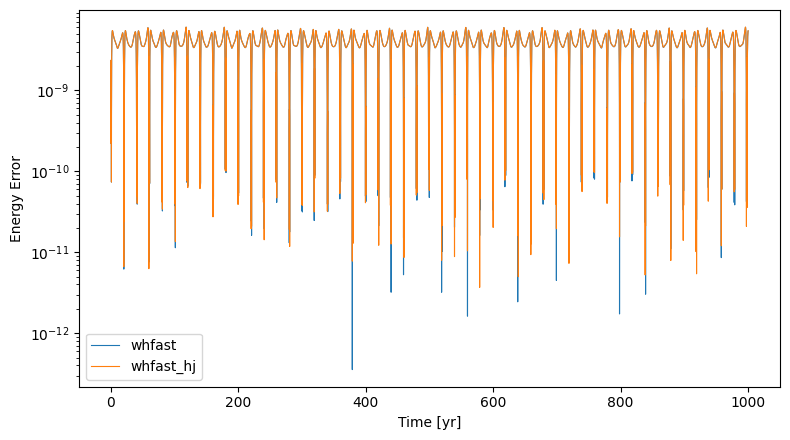

In [28]:
run_1st_experiment(print_tree=False, factor=1)

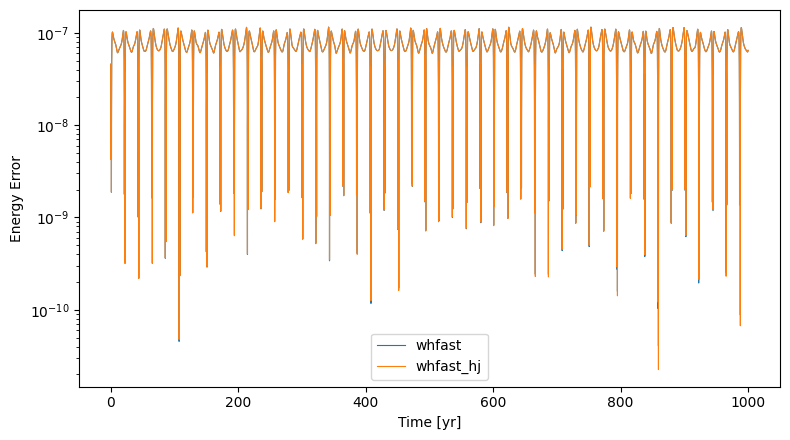

In [29]:
run_1st_experiment(print_tree=False, factor=20)

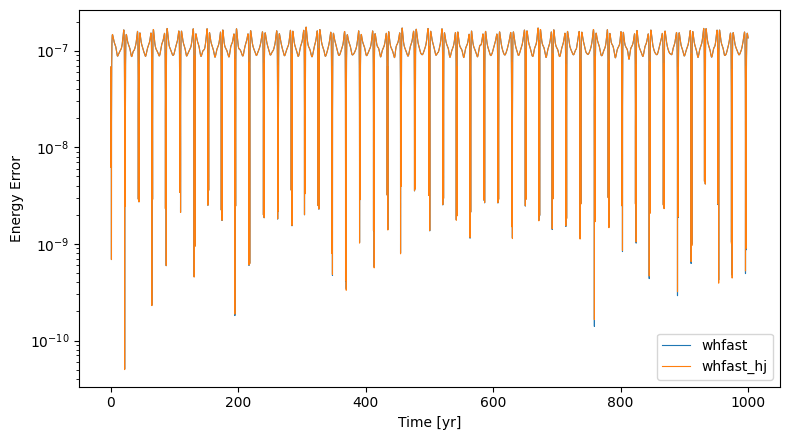

In [30]:
run_1st_experiment(print_tree=False, factor=30)


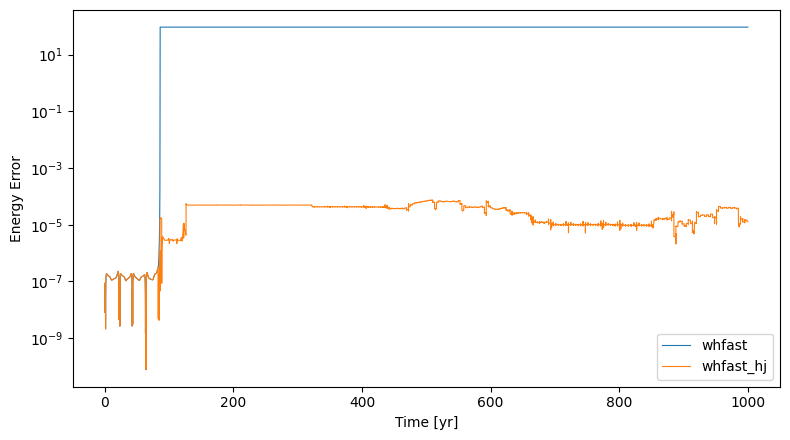

In [31]:
run_1st_experiment(print_tree=False, factor=40)

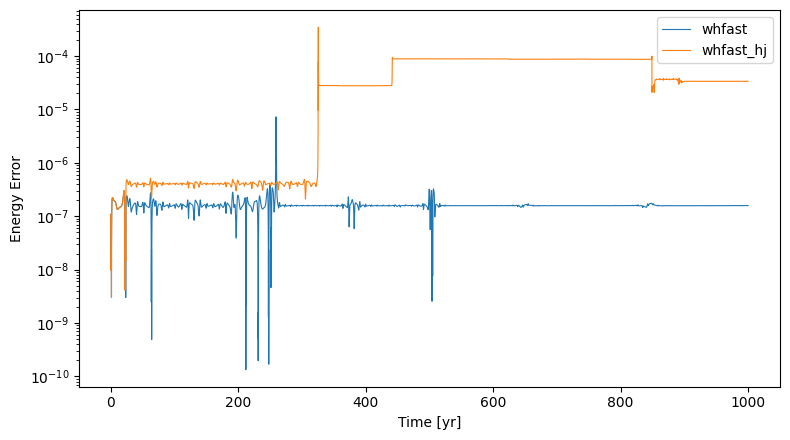

In [38]:
run_1st_experiment(print_tree=False, factor=50)

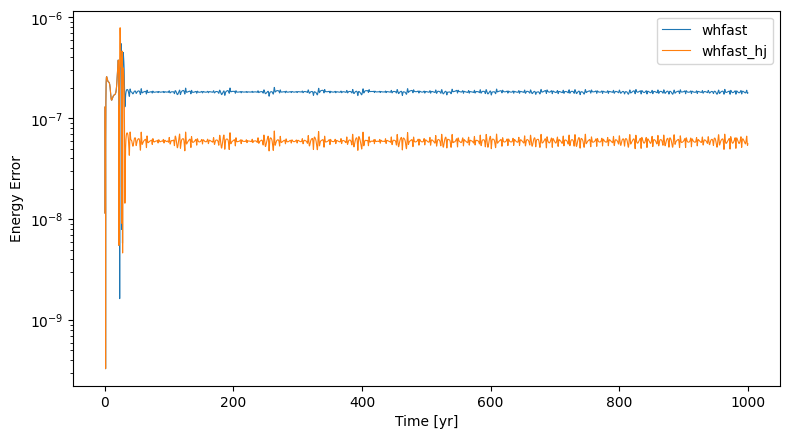

In [33]:
run_1st_experiment(print_tree=False, factor=60)

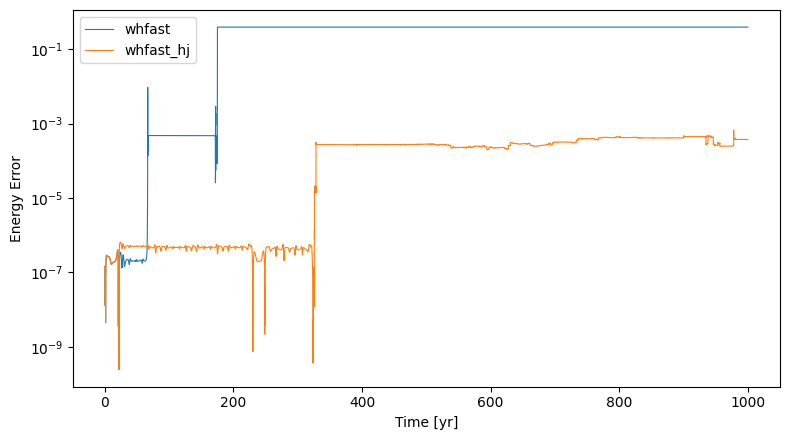

In [34]:
run_1st_experiment(print_tree=False, factor=70)

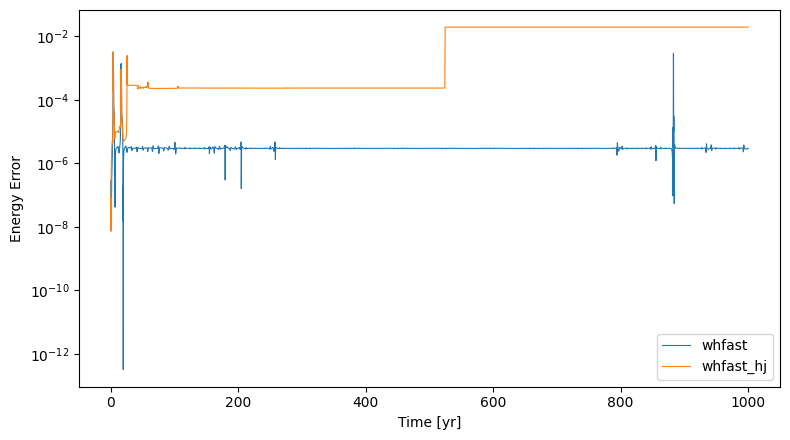

In [37]:
run_1st_experiment(print_tree=False, factor=200)

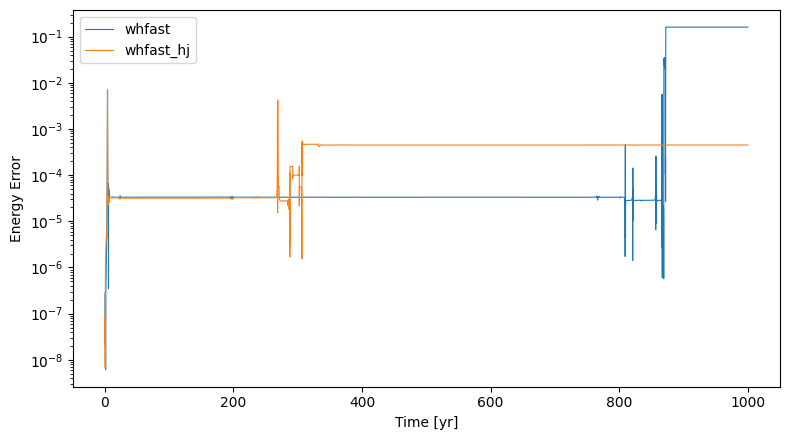

In [59]:
run_1st_experiment(print_tree=False, factor=204)


In [ ]:
# second experiment: simulation of Neptune and 36 test particles, 1000000 years.

M_NEPTUNE = 5.1501506183145834e-5

def setup_chambers_2nd_experiment(n_particles=36):
    sim = rebound.Simulation()
    sim.units = ("yr", "AU", "Msun")
    sim.G = 4*np.pi**2

    sim.add(m=1.0)

    sim.add(
        m=M_NEPTUNE,
        a=30.0,
        e=0.0,
        inc=0.0,
        Omega=0.0,
        omega=0.0,
        M=0.0,
        primary=sim.particles[0],
    )

    for k in range(n_particles):
        M_anom = 2*np.pi*k/n_particles
        sim.add(
            m=0.0,
            a=36.0,
            e=0.18,
            inc=0.0,
            Omega=0.0,
            omega=0.0,
            M=M_anom,
            primary=sim.particles[0],
        )

    sim.N_active = 2
    sim.testparticle_type = 0
    sim.move_to_com()

    return sim


def jacobi_constants(sim):
    ps = sim.particles
    star = ps[0]
    planet = ps[1]

    n = np.sqrt(sim.G*(star.m + planet.m)/30.0**3)

    rstar = np.array(star.xyz)
    rplanet = np.array(planet.xyz)

    Cs = []
    for p in ps[2:]:
        r = np.array(p.xyz)
        v = np.array(p.vxyz)

        KE = 0.5*np.dot(v, v)

        r1 = r - rstar
        r2 = r - rplanet
        PE = (
            -sim.G*star.m/np.sqrt(np.dot(r1, r1))
            -sim.G*planet.m/np.sqrt(np.dot(r2, r2))
        )

        lz = np.cross(r, v)[-1]
        C = 2*n*lz - 2*(KE + PE)
        Cs.append(C)

    return np.array(Cs)

In [71]:
def run_jacobi_error(integrator, tmax=1e6, sample_every=20,dt=5.0):
    sim = setup_chambers_2nd_experiment()
    sim.integrator = integrator
    sim.dt = dt

    C0 = jacobi_constants(sim)

    times = [sim.t]
    max_errors = [0.0]

    nsteps = int(tmax / sim.dt)

    for i in range(nsteps):
        sim.integrate(sim.t + sim.dt)

        if (i + 1) % sample_every == 0:
            C = jacobi_constants(sim)
            rel_errors = np.abs((C - C0) / C0)

            times.append(sim.t)
            max_errors.append(np.max(rel_errors))

    return np.array(times), np.array(max_errors)

def run_2nd_experiment(dt=5,tmax=1e6):   
    plt.figure(figsize=(8, 4.5))

    for integrator in ["whfast", "whfast_hj"]:
        times, errors = run_jacobi_error(integrator, tmax=tmax, dt=dt)  # try 1e4 first
        errors[errors == 0.0] = np.nan
        plt.semilogy(times, errors, label=integrator, linewidth=0.8)

    plt.xlabel("Time [yr]")
    plt.ylabel("Max relative Jacobi error")
    plt.legend()
    plt.tight_layout()
    plt.show()

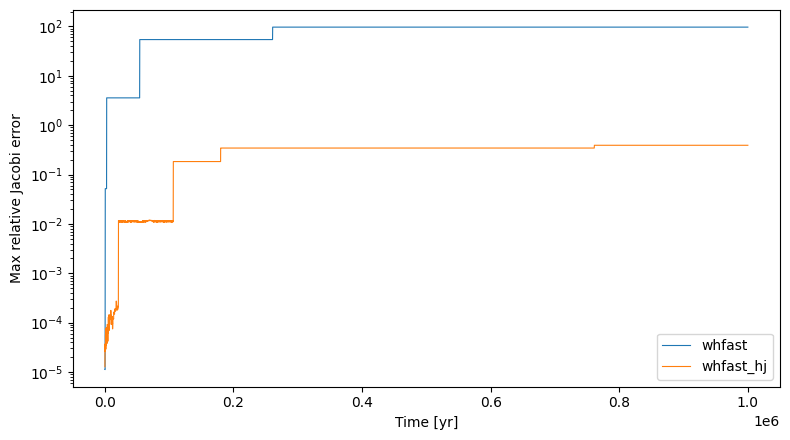

In [75]:
run_2nd_experiment(dt=2.5,tmax=1e6)

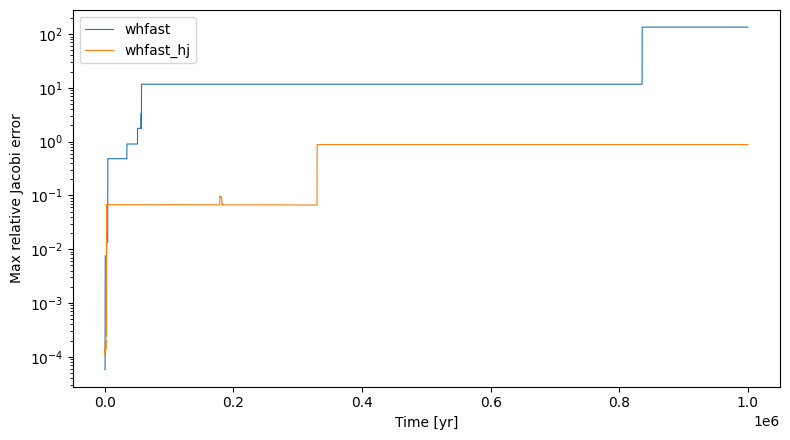

In [73]:
run_2nd_experiment(dt=5.0,tmax=1e6)


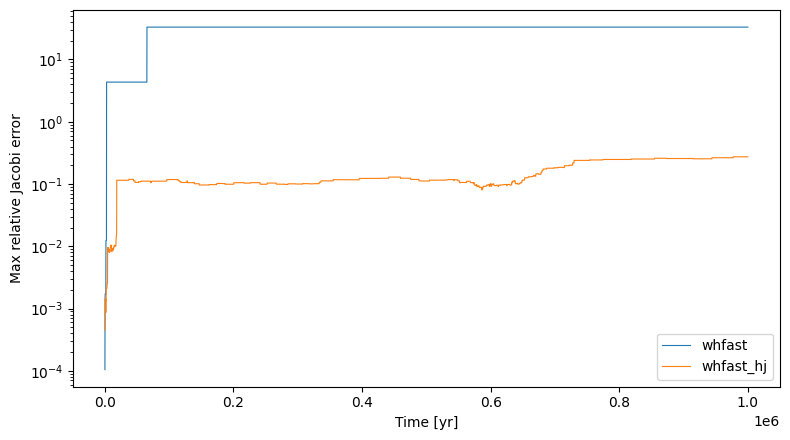

In [74]:
run_2nd_experiment(dt=10.0,tmax=1e6)

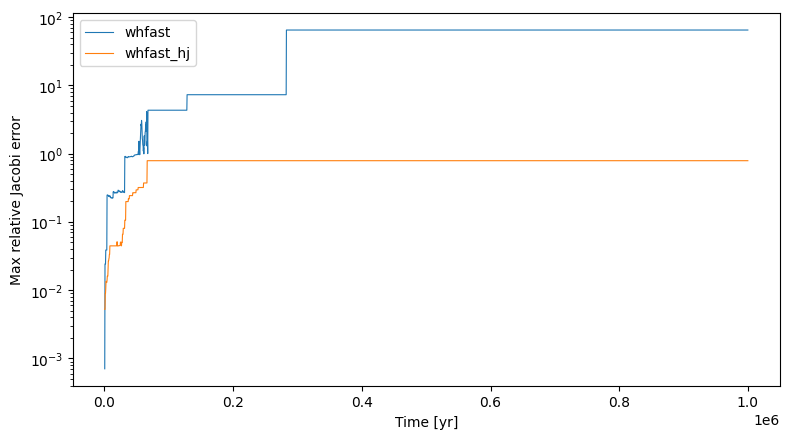

In [76]:
run_2nd_experiment(dt=20.0,tmax=1e6)


In [80]:
# third experiment: 30 planetary embryos, 10000 years

M_EARTH = 3.00348959632e-6   # Msun
M_MOON = 3.694303349e-8      # Msun
EXP3_DT = 5.0 / 365.25       # 5 days in years


def setup_chambers_3rd_experiment(n_embryos=30, seed=1):
    rng = np.random.default_rng(seed)

    sim = rebound.Simulation()
    sim.units = ("yr", "AU", "Msun")
    sim.G = 4*np.pi**2

    sim.add(m=1.0)

    masses = rng.uniform(0.6*M_MOON, 0.2*M_EARTH, n_embryos)
    semi_major_axes = rng.uniform(0.5, 1.2, n_embryos)
    eccentricities = rng.uniform(0.0, 0.01, n_embryos)

    for m, a, e in zip(masses, semi_major_axes, eccentricities):
        sim.add(
            m=m,
            a=a,
            e=e,
            inc=0.0,
            Omega=0.0,
            omega=rng.uniform(0.0, 2*np.pi),
            M=rng.uniform(0.0, 2*np.pi),
            primary=sim.particles[0],
        )

    sim.move_to_com()
    sim.dt = EXP3_DT

    return sim


def run_embryo_energy_error(
    integrator,
    tmax=10000.0,
    dt=EXP3_DT,
    sample_every=100,
    seed=1,
):
    sim = setup_chambers_3rd_experiment(seed=seed)
    sim.integrator = integrator
    sim.dt = dt

    E0 = sim.energy()
    nsteps = int(tmax / sim.dt)

    times = [sim.t]
    energy_errors = [0.0]

    for i in range(nsteps):
        sim.integrate(sim.t + sim.dt)

        if (i + 1) % sample_every == 0:
            E = sim.energy()
            times.append(sim.t)
            energy_errors.append((E - E0) / E0)

    return np.array(times), np.array(energy_errors)


def run_3rd_experiment(
    tmax=1000.0,
    dt=EXP3_DT,
    sample_every=100,
    seed=1,
):
    plt.figure(figsize=(8, 4.5))

    for integrator in ["whfast", "whfast_hj"]:
        times, energy_errors = run_embryo_energy_error(
            integrator,
            tmax=tmax,
            dt=dt,
            sample_every=sample_every,
            seed=seed,
        )

        abs_errors = np.abs(energy_errors)
        abs_errors[abs_errors == 0.0] = np.nan

        plt.semilogy(times, abs_errors, linewidth=0.8, label=integrator)

    plt.xlabel("Time [yr]")
    plt.ylabel("Energy Error")
    plt.legend()
    plt.tight_layout()
    plt.show()


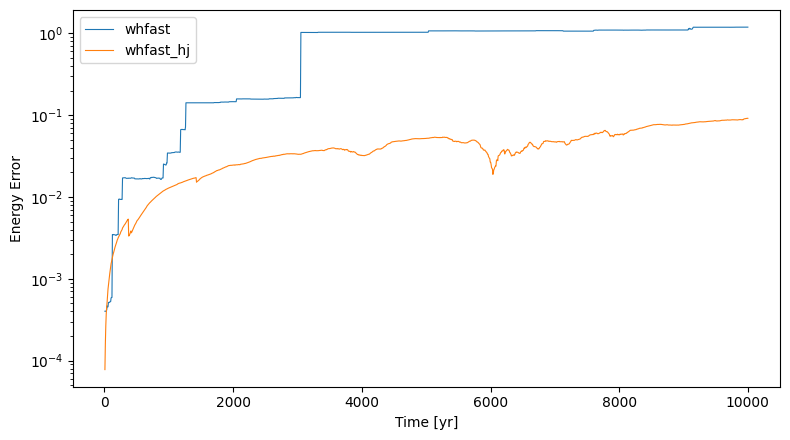

In [82]:

run_3rd_experiment(tmax=10000.0, sample_every=500, seed=1)


In [100]:
# fourth experiment: Comet P/Oterma close encounter with Jupiter

M_JUPITER_EXP4 = 9.5479e-4
EXP4_EPOCH_JD = 2426600.5
EXP4_DT = 25.0 / 365.25       # 25 days in years
EXP4_TMAX = 13400.0 / 365.25  # Michel & Valsecchi integration span


def setup_chambers_4th_experiment(
    integrator="whfast_hj",
    oterma_offset=-15,
    dt=EXP4_DT,
):
    sim = rebound.Simulation()
    sim.units = ("yr", "AU", "Msun")
    sim.G = 4*np.pi**2

    sim.add(m=1.0)
    sun = sim.particles[0]

    sim.add(
        m=M_JUPITER_EXP4,
        a=5.202465,
        e=0.048403,
        inc=np.deg2rad(1.30463),
        Omega=np.deg2rad(100.47058),
        omega=np.deg2rad(275.24335),
        M=np.deg2rad(97.44267),
        primary=sun,
    )


    M_oterma_deg = 251.54852 + 0.1*oterma_offset
    sim.add(
        m=0.0,
        a=7.043341,
        e=0.177499,
        inc=np.deg2rad(3.00283),
        Omega=np.deg2rad(32.83498),
        omega=np.deg2rad(248.18345),
        M=np.deg2rad(M_oterma_deg),
        primary=sun,
    )

    sim.N_active = 2
    sim.testparticle_type = 0
    sim.move_to_com()

    sim.integrator = integrator
    sim.dt = dt

    return sim


def oterma_rotating_coordinates(sim):
    ps = sim.particles
    r_sun = np.array(ps[0].xyz)
    r_jupiter = np.array(ps[1].xyz)
    r_oterma = np.array(ps[2].xyz)

    sun_from_jupiter = r_sun - r_jupiter
    oterma_from_jupiter = r_oterma - r_jupiter

    theta = np.pi - np.arctan2(sun_from_jupiter[1], sun_from_jupiter[0])
    c = np.cos(theta)
    s = np.sin(theta)

    x = c*oterma_from_jupiter[0] - s*oterma_from_jupiter[1]
    y = s*oterma_from_jupiter[0] + c*oterma_from_jupiter[1]
    distance = np.linalg.norm(oterma_from_jupiter)

    return x, y, distance


def run_oterma_trajectory(
    integrator,
    tmax=EXP4_TMAX,
    dt=EXP4_DT,
    oterma_offset=-15,
):
    sim = setup_chambers_4th_experiment(
        integrator=integrator,
        oterma_offset=oterma_offset,
        dt=dt,
    )

    nsteps = int(np.round(tmax / dt))
    times = []
    xs = []
    ys = []
    distances = []

    for i in range(nsteps + 1):
        x, y, distance = oterma_rotating_coordinates(sim)
        times.append(sim.t)
        xs.append(x)
        ys.append(y)
        distances.append(distance)

        if i < nsteps:
            sim.integrate((i + 1)*dt)

    return np.array(times), np.array(xs), np.array(ys), np.array(distances)


def run_4th_experiment(
    dt_days=25.0,
    tmax_days=13400.0,
    oterma_offset=-15,
    integrators=("bs", "whfast", "whfast_hj"),
    xlim=(-2.0, 2.0),
    ylim=(-2.0, 2.0),
):
    dt = dt_days / 365.25
    tmax = tmax_days / 365.25

    styles = {
        "bs": dict(color="black", linestyle="--", linewidth=1.2, label="bs reference"),
        "ias15": dict(color="black", linestyle="--", linewidth=1.2, label="ias15 reference"),
        "whfast": dict(linewidth=0.9, label="whfast"),
        "whfast_hj": dict(linewidth=0.9, label="whfast_hj"),
    }

    plt.figure(figsize=(6, 6))
    results = {}

    for integrator in integrators:
        times, xs, ys, distances = run_oterma_trajectory(
            integrator,
            tmax=tmax,
            dt=dt,
            oterma_offset=oterma_offset,
        )
        results[integrator] = (times, xs, ys, distances)

        closest = np.argmin(distances)
        print(
            f"{integrator}: closest sampled distance = {distances[closest]:.5f} AU "
            f"at t = {times[closest]*365.25:.1f} days"
        )

        plt.plot(xs, ys, **styles.get(integrator, dict(linewidth=0.9, label=integrator)))

    plt.scatter([0.0], [0.0], s=50, color="gold", edgecolor="black", zorder=5, label="Jupiter")
    if xlim is not None:
        plt.xlim(*xlim)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("x relative to Jupiter [AU]")
    plt.ylabel("y relative to Jupiter [AU]")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return results


bs: closest sampled distance = 0.04108 AU at t = 3625.0 days
whfast: closest sampled distance = 0.03776 AU at t = 3800.0 days
whfast_hj: closest sampled distance = 0.04307 AU at t = 3625.0 days


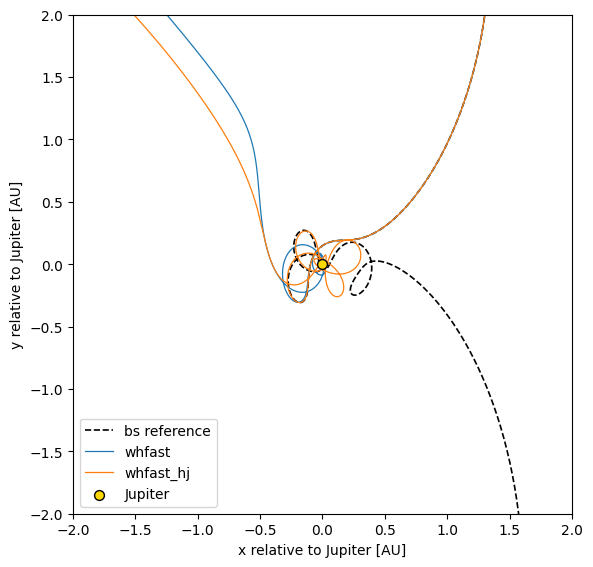

In [101]:
exp04_results = run_4th_experiment(dt_days=25.0, oterma_offset=-15)


In [ ]:
comet